# spatial transcriptomic section (Slide-seq_29) to Allen Brain Atlas

This tutorial demonstrates omic-to-image alignment by registering the Slide-seq_29 spatial omics section to the Allen Brain Atlas image reference.

Tutorial 1: spatial omics to CCF (omic-to-image)

## 1. Load package and data paths

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import cv2
try:
    START_DIR = Path(__file__).resolve().parent
except NameError:
    START_DIR = Path.cwd()

PROJECT_ROOT = next(
    candidate for candidate in (START_DIR, *START_DIR.parents)
    if (candidate / "SPOmiAlign").is_dir()
)
spomialign_path = PROJECT_ROOT / "SPOmiAlign"

if str(spomialign_path) not in sys.path:
    sys.path.insert(0, str(spomialign_path))

from tutorial_utils import (
    generate_ssi_visualization,
    get_tutorial_paths,
    run_omic_to_image_alignment,
    read_bgr,
)

DATA_DIR, OUTPUT_ROOT = get_tutorial_paths(PROJECT_ROOT)
SAMPLE_ID = "PUCK29"
SOURCE_OMIC_PATH = "Tutorial 1 spatial omics to CCF (omic-to-image)/Puck_Num_29.h5ad"
TARGET_IMAGE_PATH = "Tutorial 1 spatial omics to CCF (omic-to-image)/CCF_100048576_205.png"
SSI_IMAGE_PATH = None
%matplotlib inline

[OK] Successfully imported 'rasterize_h5ad_to_image' from data_process.py
Data directory: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/Data
Output directory: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output


## 2. Parameter settings

| Parameter | Meaning |
| --- | --- |
| `SAMPLE_ID` | Output folder name under `output/h5ad_2_img/`. |
| `SOURCE_OMIC_PATH` | Source spatial omics h5ad path in data. |
| `TARGET_IMAGE_PATH` | Reference image path in data. |
| `SSI_IMAGE_PATH` | The path of rendered SSI image. |
| `manual_rotate` | Clockwise manual rotation applied when rendering the source h5ad into SSI. |
| `SSI_dpi` | SSI rendering resolution. The default value is 150. |
| `x_coordinate` / `y_coordinate` | Spot coordinate columns used for SSI rendering. |
| `SPOT_UMI` | UMI is calculated by default; use this h5ad obs key if available. |
| `threshold_percentile` | Optional intensity(UMI) percentile filter; `None` keeps all valid spots. |
| `SPOT` | Spot shape (`square` / `circle`) and visualization radius. |
| `Alignment_mode` | SPOmiAlign supports three alignment modes: Rigid (`Rigid`), Affine (`Affine`, `Homography`), and Non-Rigid (`bspline`, `affine+bspline`). |
| `device` | Torch device used by alignment, for example `cuda:0`, `cuda:1`, or `cpu`; `None` keeps automatic selection. |


In [2]:
SSI_PARAMS = {
    "manual_rotate": 180,
    "SSI_dpi": 150,
    "x_coordinate": "Raw_Slideseq_X",
    "y_coordinate": "Raw_Slideseq_Y",
    "SPOT_UMI": "nFeature_Spatial",
    "threshold_percentile": 80,
    "SPOT": {"shape": "circle", "radius": 5},
}

ALIGNMENT_PARAMS = {
    "Alignment_mode": "affine+bspline",
    "device": "cuda:0",
}
SAMPLE_ID, SOURCE_OMIC_PATH, TARGET_IMAGE_PATH, SSI_IMAGE_PATH, SSI_PARAMS, ALIGNMENT_PARAMS

('PUCK29',
 'Tutorial 1 spatial omics to CCF (omic-to-image)/Puck_Num_29.h5ad',
 'Tutorial 1 spatial omics to CCF (omic-to-image)/CCF_100048576_205.png',
 None,
 {'manual_rotate': 180,
  'SSI_dpi': 150,
  'x_coordinate': 'Raw_Slideseq_X',
  'y_coordinate': 'Raw_Slideseq_Y',
  'SPOT_UMI': 'nFeature_Spatial',
  'threshold_percentile': 80,
  'SPOT': {'shape': 'circle', 'radius': 5}},
 {'Alignment_mode': 'affine+bspline', 'device': 'cuda:0'})

## 3. Generate SSI image

The SSI image is generated from the spatial omics h5ad before alignment. For these Slide-seq examples, spot coordinates are read from `Raw_Slideseq_X` and `Raw_Slideseq_Y`, and spot intensity is read from `nFeature_Spatial`.

[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_img/PUCK29/PUCK29_SSI.png (4787x5532, background=black, shape=circle, points=42664)


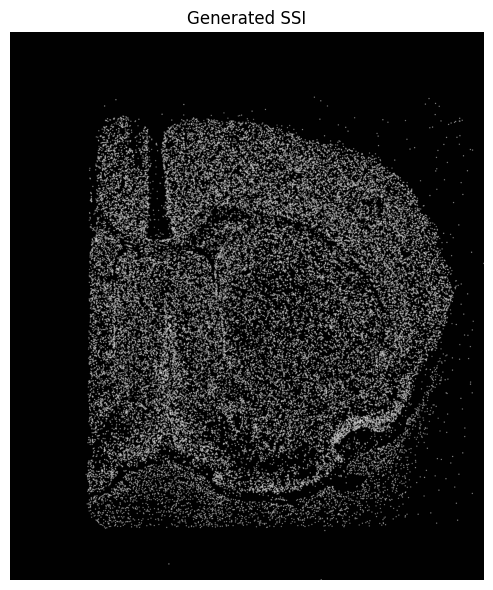

In [3]:
ssi = generate_ssi_visualization(
    data_root=DATA_DIR,
    output_root=OUTPUT_ROOT,
    sample_id=SAMPLE_ID,
    source_omic_path=SOURCE_OMIC_PATH,
    **SSI_PARAMS,
)
images=[ssi["source_section_visualization"]]
titles=["Generated SSI"]
figsize=(6, 6)
titles = titles or ["" for _ in images]
if figsize is None:
    figsize = (5.5 * len(images), 5.5)
fig, axes = plt.subplots(1, len(images), figsize=figsize)
if len(images) == 1:
    axes = [axes]
for ax, image_or_path, title in zip(axes, images, titles):
    image = read_bgr(image_or_path) if isinstance(image_or_path, (str, Path)) else image_or_path
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Run SPOmiAlign

[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_img/PUCK29/PUCK29_SSI.png (4787x5532, background=black, shape=circle, points=42664)
Using device: cuda:0


2026-05-15 08:43:54.413 | INFO     | romatch.models.model_zoo.roma_models:roma_model:61 - Using coarse resolution (560, 560), and upsample res (864, 1152)


Running RoMa matching...
Estimating affine+bspline transform...
Warping images...
Padding fill color: (1, 1, 1)
Processing H5AD coordinates...
Raw_Slideseq_X Raw_Slideseq_Y
[OK] Step 00 source coordinates mapped to render space: 213885/213885 points inside canvas -> /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_img/PUCK29/alignment/debug_step_00_source_in_render_space.png
Applying manual pre-transform: rotate=180.0°, scale=1.0
[OK] Step 01 after manual pre-transform (source canvas): 213882/213885 points inside canvas -> /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_img/PUCK29/alignment/debug_step_01_after_manual_pretransform.png
[OK] Step 02 after resize to registration grid (source resized canvas): 213880/213885 points inside canvas -> /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_img/PUCK29/alignment/debug_step_02_after_resize_to_registration.png
[OK] Step 03 after registration transform (target resized canvas): 

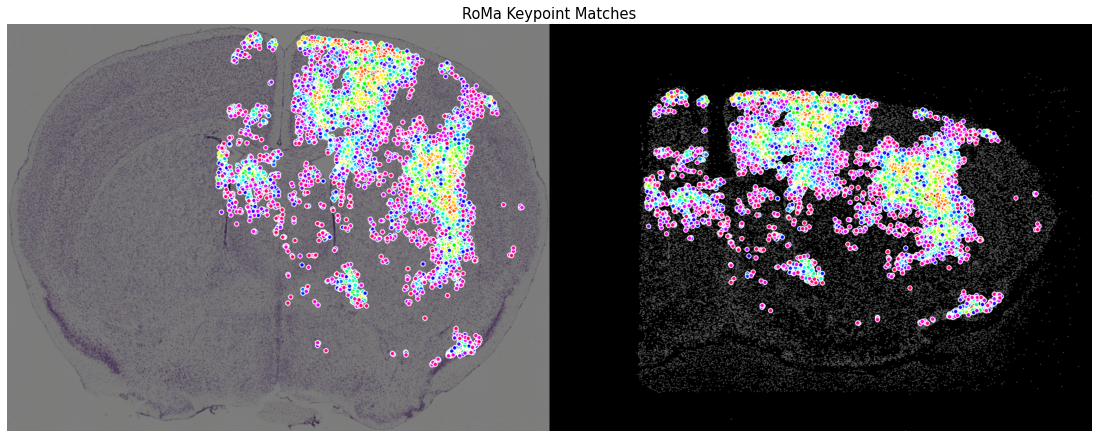

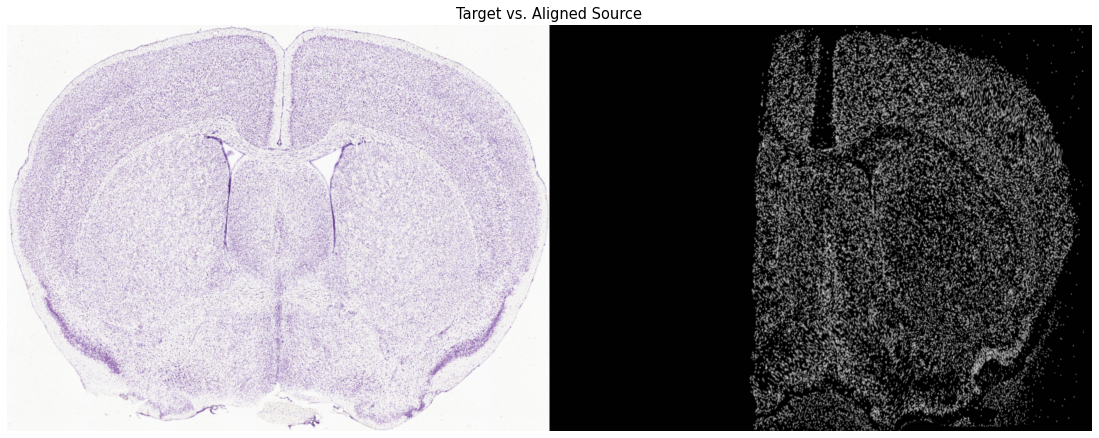

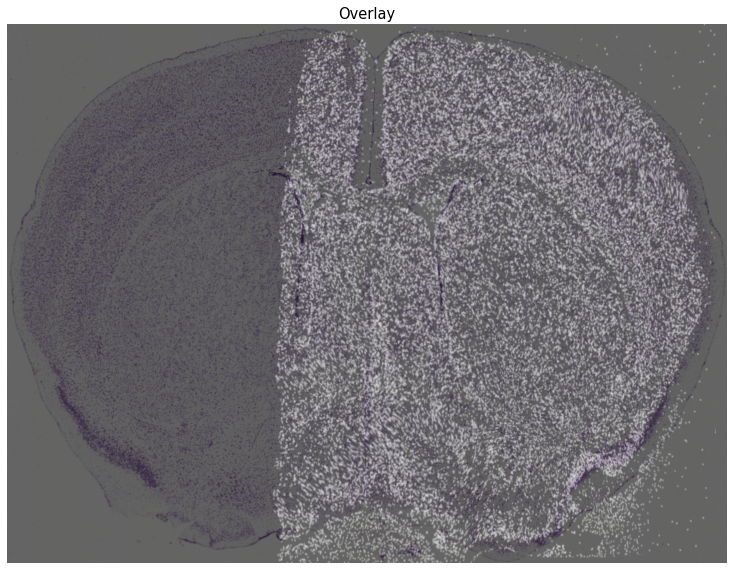

Alignment runtime: 31.7036 seconds
Done. Results saved to /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_img/PUCK29/alignment
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_img/PUCK29/alignment/transformed_h5ad_scatter.png (5587x4183, background=black, shape=circle, points=42664)


In [4]:
result = run_omic_to_image_alignment(
    data_root=DATA_DIR,
    output_root=OUTPUT_ROOT,
    sample_id=SAMPLE_ID,
    source_omic_path=SOURCE_OMIC_PATH,
    target_image_path=TARGET_IMAGE_PATH,
    SSI_IMAGE_PATH=SSI_IMAGE_PATH,
    **SSI_PARAMS,
    **ALIGNMENT_PARAMS,
)

## 5. Outputs

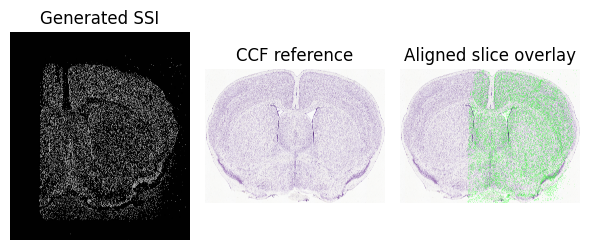

Save transformed h5ad path to  /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/h5ad_2_img/PUCK29/alignment/transformed.h5ad


In [5]:
images=[result["source_section_visualization"], result["target_section_visualization"], result["overlay"]]
titles=["Generated SSI", "CCF reference", "Aligned slice overlay"]
figsize=(6, 6)
titles = titles or ["" for _ in images]
if figsize is None:
    figsize = (5.5 * len(images), 5.5)
fig, axes = plt.subplots(1, len(images), figsize=figsize)
if len(images) == 1:
    axes = [axes]
for ax, image_or_path, title in zip(axes, images, titles):
    image = read_bgr(image_or_path) if isinstance(image_or_path, (str, Path)) else image_or_path
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()
print("Save transformed h5ad path to ", result["transformed_h5ad"])